# Quantitative Exploration of the Overnight Holding Effect in US Equities

## Research Methodology & Rigorous Style Shift Analysis

This notebook investigates the **Overnight Holding Effect** (also known as the Night Effect) — the historical tendency of equities to experience different return characteristics during overnight hours (Close-to-Open) compared to intraday trading hours (Open-to-Close).

### Modern Quantitative Research Framework:
1. **Flat Procedural Pipeline**: Following professional research standards, we avoid complex encapsulation and expose intermediate dataframes (daily returns, yearly aggregates, sector matrices) globally for instant, ad-hoc inspection and debugging.
2. **US Major Exchanges Filter**: We filter our universe for US stocks listed on major exchanges (`NYSE`, `NASDAQ`, `AMEX`) to eliminate foreign exchange/timezone noise and illiquid OTC penny stocks.
3. **Dual Ratio Metrics**: In addition to overall compounded returns, we calculate:
   - **Positive Gain Ratio**: Average positive overnight returns vs. average positive intraday returns (capturing upside participation).
   - **Negative Loss Ratio**: Average negative overnight returns vs. average negative intraday returns (capturing downside protection).
4. **Continuous Regression & Trend Detection**: Rather than using arbitrary pre/post-2015 split eras, we perform continuous rolling analysis and run linear regressions on sector/industry trends over time to rigorously compute slopes and p-values.
5. **High-Resolution Micro Visualizations**: We implement an aesthetic plotting routine using `mplfinance` to render daily OHLCV candlesticks side-by-side with rolling positive gain and negative loss ratios for any specific stock.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import mplfinance as mpf
from tqdm.auto import tqdm

# --- CONFIGURATION ---
DATA_DIR = '/opt/rws/data/fmp/fmp-daily'
PROFILES_PATH = '/opt/rws/data/fmp/fmp-company-profiles.csv'
US_EXCHANGES = ['NYSE', 'NASDAQ', 'AMEX']

In [2]:
# 1. Load and filter profiles for major US exchanges
profiles_df = pd.read_csv(PROFILES_PATH, low_memory=False)
us_profiles = profiles_df[
    (profiles_df['country'] == 'US') & 
    (profiles_df['exchange'].isin(US_EXCHANGES))
].copy()

us_profiles['symbol_key'] = us_profiles['symbol'].astype(str).str.replace('.', '_', regex=False).str.replace('/', '_', regex=False)
profiles_dict = us_profiles.set_index('symbol_key')[['symbol', 'companyName', 'sector', 'industry', 'exchange']].to_dict(orient='index')
print(f"Successfully loaded and filtered {len(profiles_dict)} US exchange-listed company profiles.")

Successfully loaded and filtered 13065 US exchange-listed company profiles.


In [3]:
# 2. Recursively find and filter price files matching our US major universe
search_pattern = os.path.join(DATA_DIR, '**', '*.parquet')
parquet_files = glob.glob(search_pattern, recursive=True)
if not parquet_files:
    search_pattern = os.path.join(DATA_DIR, '*.parquet')
    parquet_files = glob.glob(search_pattern)
    
filtered_files = []
for f in parquet_files:
    sym_key = os.path.splitext(os.path.basename(f))[0]
    if sym_key in profiles_dict:
        filtered_files.append((f, sym_key))
        
print(f"Found {len(parquet_files)} price files. Filtered down to {len(filtered_files)} US exchange-listed files.")

Found 18709 price files. Filtered down to 3253 US exchange-listed files.


### Step-by-Step Data Transformation Sanity Check

Let's trace exactly how the raw OHLCV daily data is parsed and transformed into our custom returns, ratio splits, and yearly compounded metrics for a single representative stock (e.g. `AAPL`).

In [4]:
# Sanity Check A: Load raw OHLCV for AAPL
test_file = [f for f, k in filtered_files if k == 'AAPL'][0]
raw_df = pd.read_parquet(test_file)
print("Step A: Raw OHLCV Data (First 5 Rows):")
display(raw_df.head())

Step A: Raw OHLCV Data (First 5 Rows):


,symbol,date,open,high,low,close,volume,change,changePercent,vwap
0,AAPL,1990-03-05,0.30134,0.31027,0.29911,0.30804,182470579,0.006696,2.22000,0.30469
1,AAPL,1990-03-06,0.30804,0.31473,0.30804,0.31473,156016156,0.006697,2.17000,0.31139
2,AAPL,1990-03-07,0.31473,0.32143,0.31250,0.31585,204221004,0.001116,0.35586,0.31613
3,AAPL,1990-03-08,0.31585,0.33036,0.31250,0.32813,223843420,0.012277,3.89000,0.32171
4,AAPL,1990-03-09,0.32813,0.33482,0.32366,0.32924,230473828,0.001116,0.33828,0.32896


In [5]:
# Sanity Check B: Calculate Daily Returns
raw_df['date'] = pd.to_datetime(raw_df['date'])
raw_df = raw_df.sort_values('date').reset_index(drop=True)
close_prev = raw_df['close'].shift(1)

raw_df['intraday_return'] = (raw_df['close'] - raw_df['open']) / raw_df['open']
raw_df['overnight_return'] = (raw_df['open'] - close_prev) / close_prev
raw_df['total_return'] = (raw_df['close'] - close_prev) / close_prev

print("Step B: Data with Daily Returns (First 5 Rows):")
display(raw_df.dropna(subset=['intraday_return', 'overnight_return', 'total_return']).head())

Step B: Data with Daily Returns (First 5 Rows):


,symbol,date,open,high,low,close,volume,change,changePercent,vwap,intraday_return,overnight_return,total_return
1,AAPL,1990-03-06,0.30804,0.31473,0.30804,0.31473,156016156,0.006697,2.17000,0.31139,0.021718,0.0,0.021718
2,AAPL,1990-03-07,0.31473,0.32143,0.31250,0.31585,204221004,0.001116,0.35586,0.31613,0.003559,0.0,0.003559
3,AAPL,1990-03-08,0.31585,0.33036,0.31250,0.32813,223843420,0.012277,3.89000,0.32171,0.038879,0.0,0.038879
4,AAPL,1990-03-09,0.32813,0.33482,0.32366,0.32924,230473828,0.001116,0.33828,0.32896,0.003383,0.0,0.003383
5,AAPL,1990-03-12,0.32924,0.33482,0.32366,0.32701,163956960,-0.002232,-0.67732,0.32868,-0.006773,0.0,-0.006773


In [6]:
# Sanity Check C: Filter positive / negative days
clean_df = raw_df.dropna(subset=['intraday_return', 'overnight_return', 'total_return']).copy()
clean_df['year'] = clean_df['date'].dt.year

sample_year = clean_df[clean_df['year'] == 2022]
pos_over = sample_year['overnight_return'][sample_year['overnight_return'] > 0]
pos_intra = sample_year['intraday_return'][sample_year['intraday_return'] > 0]

print(f"Step C: Positive Days Analysis for AAPL (Year 2022):")
print(f"Positive Overnight Days: {len(pos_over)} (Mean: {pos_over.mean()*100:.4f}%)")
print(f"Positive Intraday Days: {len(pos_intra)} (Mean: {pos_intra.mean()*100:.4f}%)")

Step C: Positive Days Analysis for AAPL (Year 2022):
Positive Overnight Days: 113 (Mean: 0.8480%)
Positive Intraday Days: 127 (Mean: 1.5186%)


In [7]:
# Sanity Check D: Yearly compounded aggregates on single stock
yearly_test = []
for year, group in clean_df.groupby('year'):
    cum_intra = (1 + group['intraday_return']).prod() - 1
    cum_over = (1 + group['overnight_return']).prod() - 1
    
    # Split performance on positive/negative days
    pos_over_mean = group['overnight_return'][group['overnight_return'] > 0].mean()
    pos_intra_mean = group['intraday_return'][group['intraday_return'] > 0].mean()
    neg_over_mean = group['overnight_return'][group['overnight_return'] < 0].mean()
    neg_intra_mean = group['intraday_return'][group['intraday_return'] < 0].mean()
    
    yearly_test.append({
        'year': year,
        'cum_overnight_pct': cum_over * 100,
        'cum_intraday_pct': cum_intra * 100,
        'pos_gain_ratio': pos_over_mean / pos_intra_mean if pos_intra_mean > 0 else np.nan,
        'neg_loss_ratio': neg_over_mean / neg_intra_mean if abs(neg_intra_mean) > 0 else np.nan
    })

print("Step D: Yearly Aggregated Dataset for AAPL:")
display(pd.DataFrame(yearly_test).head(10))

Step D: Yearly Aggregated Dataset for AAPL:


,year,cum_overnight_pct,cum_intraday_pct,pos_gain_ratio,neg_loss_ratio
0,1990,12.576349,10.712784,0.708631,0.555236
1,1991,-10.301060,46.160733,0.407737,0.831973
2,1992,3.391961,2.508835,0.426958,0.530825
3,1993,-30.870900,-29.184616,0.550650,0.650016
4,1994,10.226553,20.961831,0.528334,0.422107
5,1995,45.994468,-44.016859,0.530043,0.634619
6,1996,161.202269,-74.928087,0.644577,0.609913
7,1997,27.015643,-50.496713,0.480843,0.690038
8,1998,42.878578,118.293895,0.521660,0.491931
9,1999,79.568155,39.862055,0.437489,0.407425


## Generating the Complete US Universe Yearly Panel Dataset

In [8]:
# 4. Process all US Major Exchange stocks into our high-performance panel dataset
yearly_rows = []
for file_path, symbol_key in tqdm(filtered_files, desc='Aggregating yearly panel'):
    try:
        df = pd.read_parquet(file_path)
        if df.empty or len(df) < 5:
            continue
            
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        
        # Compute daily returns
        close_prev = df['close'].shift(1)
        df['intraday_return'] = (df['close'] - df['open']) / df['open']
        df['overnight_return'] = (df['open'] - close_prev) / close_prev
        df['total_return'] = (df['close'] - close_prev) / close_prev
        
        df = df.dropna(subset=['intraday_return', 'overnight_return', 'total_return']).copy()
        if df.empty:
            continue
            
        df['year'] = df['date'].dt.year
        
        # Group by year and calculate cumulative returns & split-ratios
        for year, group in df.groupby('year'):
            # Require at least 30 trading days in a year for statistical viability
            if len(group) < 30:
                continue
                
            cum_intra = (1 + group['intraday_return']).prod() - 1
            cum_over = (1 + group['overnight_return']).prod() - 1
            cum_total = (1 + group['total_return']).prod() - 1
            
            # Split performance on positive/negative days
            pos_over_mean = group['overnight_return'][group['overnight_return'] > 0].mean()
            pos_intra_mean = group['intraday_return'][group['intraday_return'] > 0].mean()
            neg_over_mean = group['overnight_return'][group['overnight_return'] < 0].mean()
            neg_intra_mean = group['intraday_return'][group['intraday_return'] < 0].mean()
            
            meta = profiles_dict[symbol_key]
            
            yearly_rows.append({
                'year': int(year),
                'symbol': meta['symbol'],
                'symbol_key': symbol_key,
                'companyName': meta['companyName'],
                'sector': meta['sector'],
                'industry': meta['industry'],
                'exchange': meta['exchange'],
                'days': len(group),
                'cum_overnight_pct': cum_over * 100,
                'cum_intraday_pct': cum_intra * 100,
                'cum_buy_hold_pct': cum_total * 100,
                'overnight_minus_intraday_pct': (cum_over - cum_intra) * 100,
                'mean_pos_overnight_pct': pos_over_mean * 100 if not pd.isna(pos_over_mean) else 0,
                'mean_pos_intraday_pct': pos_intra_mean * 100 if not pd.isna(pos_intra_mean) else 0,
                'mean_neg_overnight_pct': neg_over_mean * 100 if not pd.isna(neg_over_mean) else 0,
                'mean_neg_intraday_pct': neg_intra_mean * 100 if not pd.isna(neg_intra_mean) else 0
            })
    except Exception:
        continue
        
panel_df = pd.DataFrame(yearly_rows)

if not panel_df.empty:
    # Rank the stocks within each year based on Overnight Premium
    panel_df['overnight_bias_rank'] = panel_df.groupby('year')['overnight_minus_intraday_pct'].rank(ascending=False, method='min')
    print(f"Successfully created yearly panel dataset with {len(panel_df)} records.")
    display(panel_df.head())
else:
    print("Warning: Created panel dataset is empty.")

Aggregating yearly panel:   0%|          | 0/3253 [00:00<?, ?it/s]

Successfully created yearly panel dataset with 60470 records.


,year,symbol,symbol_key,companyName,sector,industry,exchange,days,cum_overnight_pct,cum_intraday_pct,cum_buy_hold_pct,overnight_minus_intraday_pct,mean_pos_overnight_pct,mean_pos_intraday_pct,mean_neg_overnight_pct,mean_neg_intraday_pct,overnight_bias_rank
0,2021,XMTR,XMTR,"Xometry, Inc.",Industrials,Industrial - Machinery,NASDAQ,128,-4.650621,-38.494456,-41.354846,33.843835,0.959031,3.291966,-1.045958,-3.310976,1150.0
1,2022,XMTR,XMTR,"Xometry, Inc.",Industrials,Industrial - Machinery,NASDAQ,251,-50.278614,26.480394,-37.112195,-76.759008,1.302420,3.381768,-1.420442,-3.250487,2788.0
2,2023,XMTR,XMTR,"Xometry, Inc.",Industrials,Industrial - Machinery,NASDAQ,250,25.504507,-11.223958,11.417934,36.728466,1.403518,3.370053,-1.173478,-2.985370,494.0
3,2024,XMTR,XMTR,"Xometry, Inc.",Industrials,Industrial - Machinery,NASDAQ,252,64.469725,-27.769690,18.796992,92.239415,1.746937,2.876598,-1.483174,-2.647311,260.0
4,2025,XMTR,XMTR,"Xometry, Inc.",Industrials,Industrial - Machinery,NASDAQ,250,25.516778,11.064510,39.404594,14.452269,1.497295,2.911681,-1.378319,-2.793655,941.0


In [17]:
panel_df = panel_df[panel_df['days'] > 200].copy()

In [21]:
panel_df[panel_df['year'] == 2025].sort_values('overnight_minus_intraday_pct')

,year,symbol,symbol_key,companyName,sector,industry,exchange,days,cum_overnight_pct,cum_intraday_pct,cum_buy_hold_pct,overnight_minus_intraday_pct,mean_pos_overnight_pct,mean_pos_intraday_pct,mean_neg_overnight_pct,mean_neg_intraday_pct,overnight_bias_rank
12550,2025,RVMDW,RVMDW,"Revolution Medicines, Inc. Warrant",Healthcare,Biotechnology,NASDAQ,231,-1.000000e+02,2.770344e+12,422.166667,-2.770344e+12,13.535059,35.258915,-18.124195,-12.510859,3187.0
24395,2025,PSFE-WT,PSFE-WT,Paysafe Limited,Technology,Information Technology Services,NYSE,250,-9.980240e+01,1.567198e+05,209.883308,-1.568196e+05,16.964506,11.672498,-8.084465,-7.668544,3185.0
41625,2025,CORZW,CORZW,"Core Scientific, Inc.",Technology,Software - Infrastructure,NASDAQ,250,-8.575699e+01,6.225979e+02,2.919708,-7.083548e+02,3.639960,5.302914,-3.893421,-4.945174,3184.0
35208,2025,BMNR,BMNR,"Bitmine Immersion Technologies, Inc.",Financial Services,Financial - Capital Markets,NYSE,227,-5.018685e+01,5.987652e+02,248.076923,-6.489521e+02,8.967702,13.514748,-7.960307,-6.076726,3183.0
6226,2025,VSAT,VSAT,"Viasat, Inc.",Technology,Communication Equipment,NASDAQ,250,-2.316113e+01,4.269929e+02,304.935370,-4.501540e+02,1.697645,3.959381,-1.746961,-3.098737,3182.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13722,2025,USAR,USAR,USA Rare Earth Inc,Basic Materials,Industrial Materials,NASDAQ,249,1.527120e+03,-9.362933e+01,3.658537,1.620750e+03,3.735405,7.175314,-2.308645,-5.705092,5.0
1688,2025,ASST,ASST,"Strive, Inc.",Communication Services,Asset Management,NASDAQ,250,1.777337e+03,-9.199368e+01,50.305499,1.869330e+03,8.358681,9.251598,-4.103218,-7.328464,4.0
3434,2025,ABTC,ABTC,American Bitcoin Corp,Financial Services,Financial - Capital Markets,NASDAQ,250,2.073411e+03,-9.610855e+01,-15.422886,2.169520e+03,6.118124,7.096733,-2.837729,-5.828561,3.0
1454,2025,AUROW,AUROW,"Aurora Innovation, Inc.",Technology,Information Technology Services,NASDAQ,250,3.127450e+03,-9.934202e+01,-78.764151,3.226792e+03,6.273869,6.346050,-4.471646,-6.833306,2.0


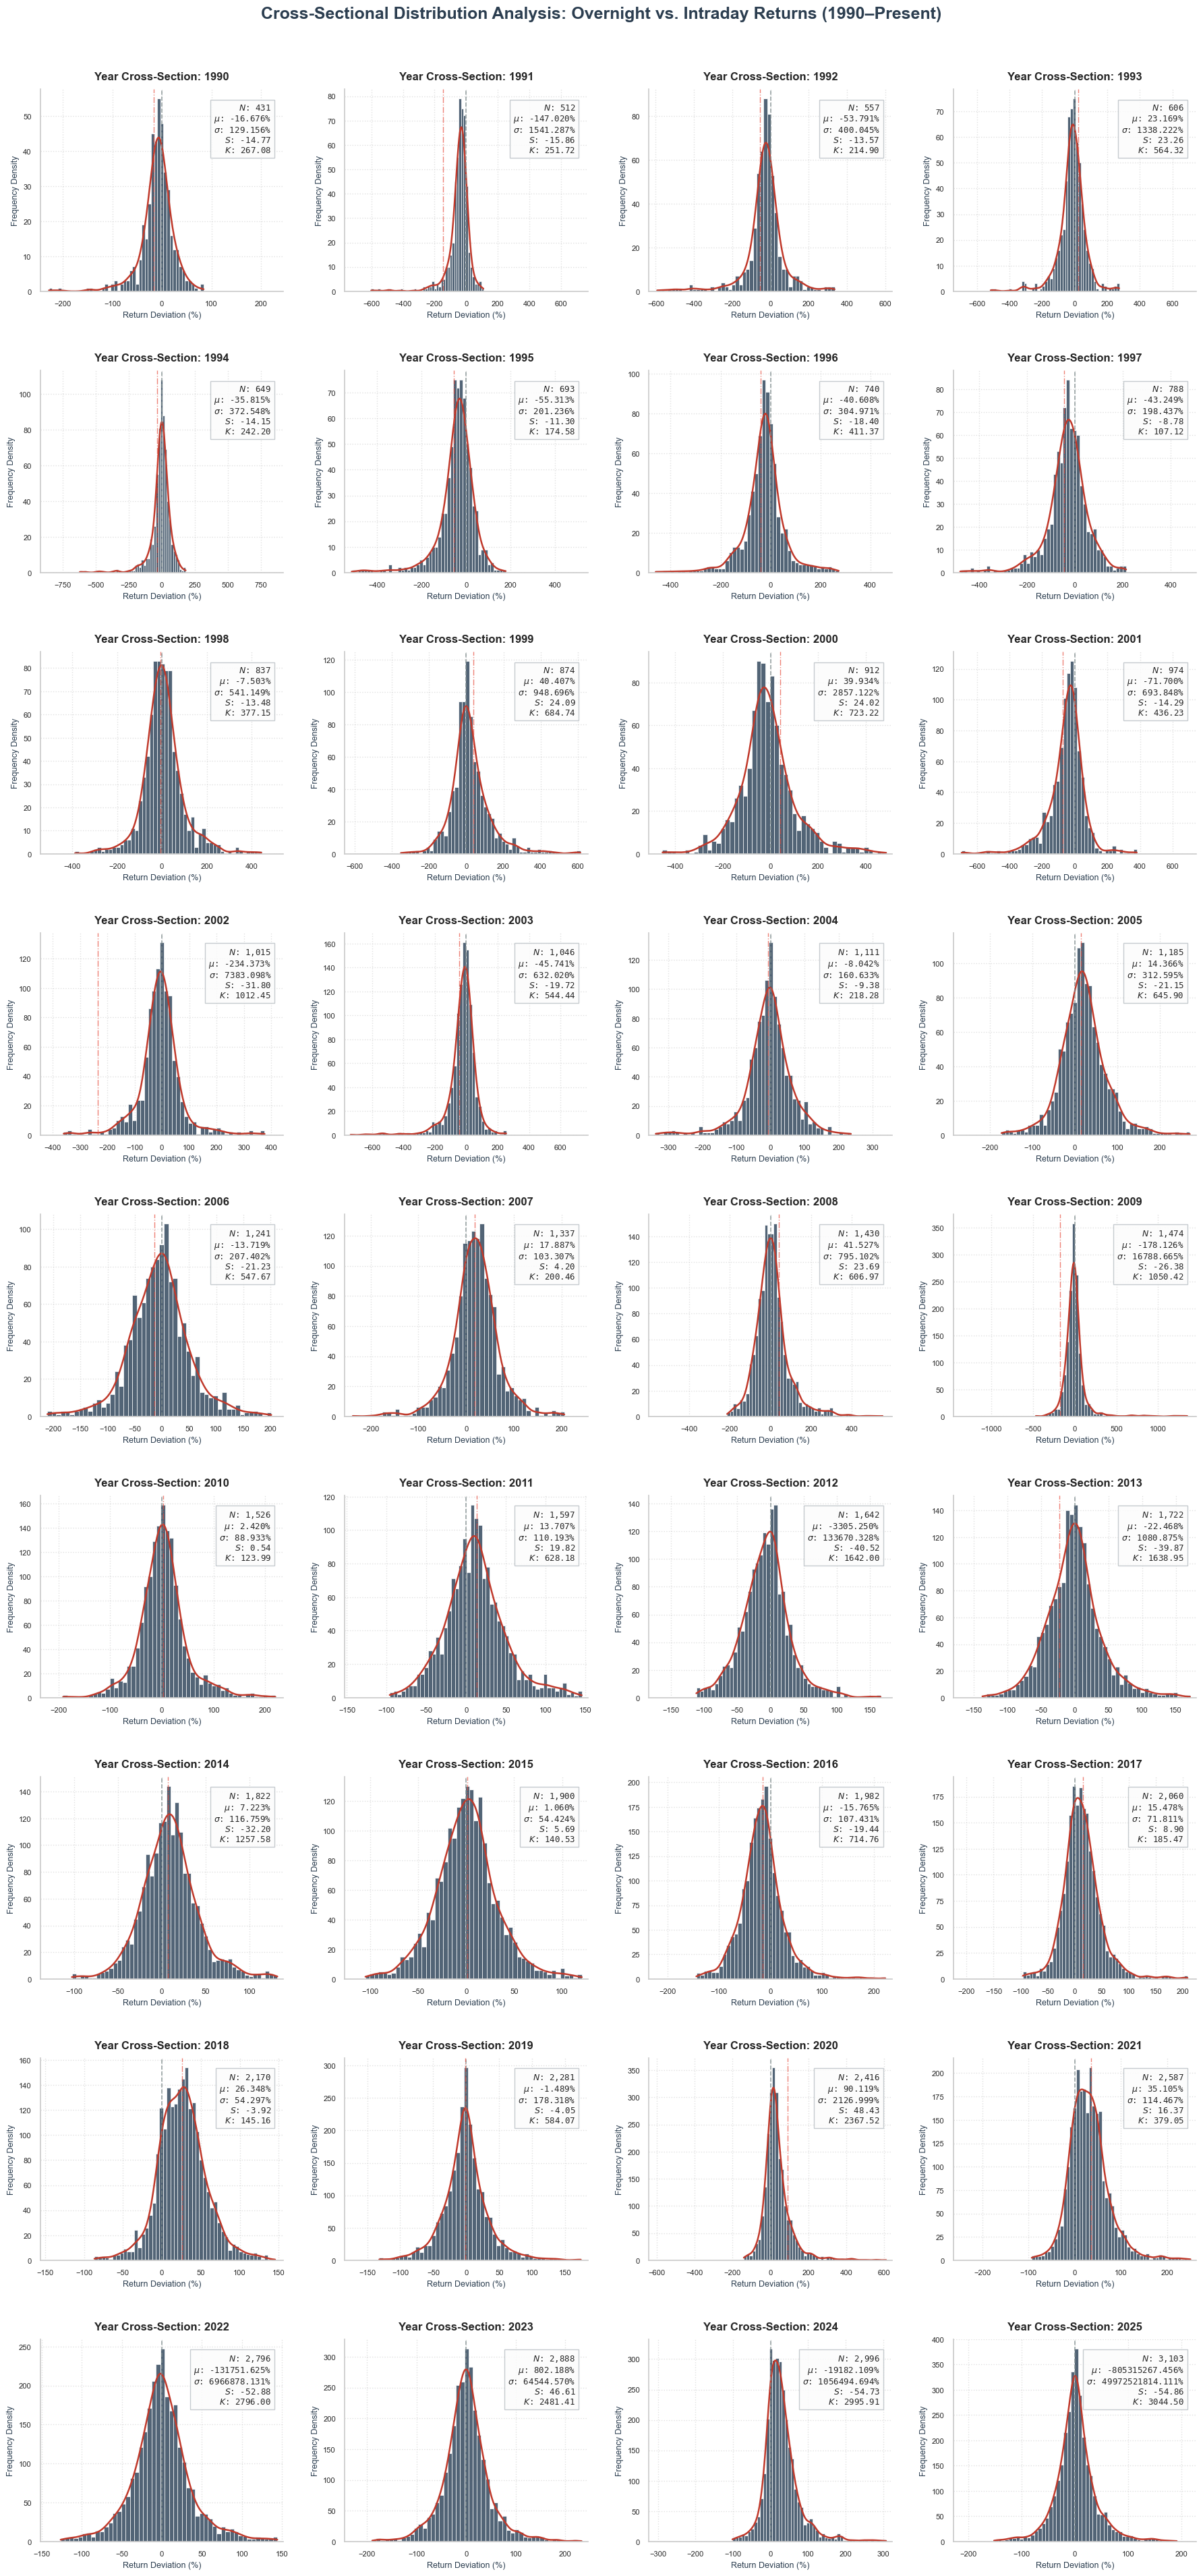

In [18]:
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Establish a rigorous scientific theme
sns.set_theme(style="whitegrid", rc={"grid.linestyle": ":", "grid.alpha": 0.6})

# Extract temporal parameters
start_year = panel_df["year"].min()
end_year = panel_df["year"].max()
years = list(range(start_year, end_year + 1))

COLS = 4
ROWS = math.ceil(len(years) / COLS)

# 2. Initialize the multi-panel figure
# We increase the vertical spacing allocation (ROWS * 4) to ensure x-labels and titles never overlap
fig, axes = plt.subplots(
    ROWS, COLS, figsize=(18, ROWS * 4.2), sharex=False, sharey=False
)
axes_flat = axes.flatten()

for i, year in enumerate(years):
    ax = axes_flat[i]
    YEAR = year

    # Filter temporal cross-section
    year_df = panel_df[panel_df["year"] == YEAR]

    if year_df.empty:
        ax.set_title(
            f"Year: {YEAR} (No Data Available)",
            fontsize=11,
            weight="bold",
            color="#2c3e50",
        )
        continue

    # Extract target vector
    raw_series = year_df["overnight_minus_intraday_pct"].dropna()

    # Calculate population metrics before outlier trimming to preserve true universe state
    n_obs = len(raw_series)
    mu = raw_series.mean()
    sigma = raw_series.std()
    skew = raw_series.skew()
    kurt = raw_series.kurt()  # Excess kurtosis

    # 3. Robust Winsorization / Truncation (1st and 99th percentiles) for visualization scaling
    lower_bound = raw_series.quantile(0.01)
    upper_bound = raw_series.quantile(0.99)
    filtered_data = raw_series[
        (raw_series >= lower_bound) & (raw_series <= upper_bound)
    ]

    # 4. Plot empirical distribution
    sns.histplot(
        filtered_data,
        kde=True,
        bins=50,
        color="#34495e",  # Professional dark slate
        edgecolor="white",
        linewidth=0.5,
        alpha=0.85,
        ax=ax,
    )

    # 5. Enforce mathematical symmetry about 0 on the x-axis
    max_val = max(abs(lower_bound), abs(upper_bound))
    # Add a 5% padding buffer so edge bins aren't clipped by the spine
    ax.set_xlim(-max_val * 1.05, max_val * 1.05)

    # 6. Statistical Reference Lines
    ax.axvline(
        x=0,
        color="#7f8c8d",
        linestyle="--",
        linewidth=1.2,
        alpha=0.8,
        label="Zero Bound",
    )
    ax.axvline(
        x=mu,
        color="#e74c3c",
        linestyle="-.",
        linewidth=1.0,
        alpha=0.7,
        label="Mean",
    )

    # 7. Refine empirical kernel density estimate (KDE) line style
    if ax.lines:
        ax.lines[0].set_color("#c0392b")  # Deep crimson for the distribution fit
        ax.lines[0].set_linewidth(1.8)

    # 8. Structural Metric Overlay (LaTeX formatting for statistical notation)
    stats_string = (
        f"$N$: {n_obs:,}\n"
        f"$\mu$: {mu:.3f}%\n"
        f"$\sigma$: {sigma:.3f}%\n"
        f"$S$: {skew:.2f}\n"
        f"$K$: {kurt:.2f}"
    )

    # Positioned transparently in the upper right quadrant
    text_props = dict(
        boxstyle="square,pad=0.4",
        facecolor="#fcfcfc",
        edgecolor="#bdc3c7",
        alpha=0.85,
    )
    ax.text(
        0.95,
        0.93,
        stats_string,
        transform=ax.transAxes,
        fontsize=9,
        fontfamily="monospace",
        verticalalignment="top",
        horizontalalignment="right",
        bbox=text_props,
    )

    # 9. Individual Axis Customization (Ensuring explicit labels for every sub-panel)
    ax.set_title(f"Year Cross-Section: {YEAR}", fontsize=12, weight="bold", pad=10)
    ax.set_xlabel("Return Deviation (%)", fontsize=9, color="#2c3e50")
    ax.set_ylabel("Frequency Density", fontsize=9, color="#2c3e50")
    ax.tick_params(axis="both", which="major", labelsize=8)

# 10. Prune unpopulated subplots in the matrix grid
for j in range(len(years), len(axes_flat)):
    fig.delaxes(axes_flat[j])

# 11. Global Layout Infrastructure
fig.suptitle(
    "Cross-Sectional Distribution Analysis: Overnight vs. Intraday Returns (1990–Present)",
    fontsize=18,
    weight="bold",
    y=1.01,
    color="#2c3e50",
)

# Apply standard scientific bounding
sns.despine(left=False, bottom=False)
plt.tight_layout(h_pad=3.0, w_pad=2.0)
plt.show()

In [12]:
import base64
import io
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from weasyprint import HTML

def generate_sector_distribution_pdf(panel_df, output_filename="quantamental_sector_report.pdf"):
    """
    Groups data by Sector and Year, performs statistical tests, and exports 
    a PDF report with symmetrically zero-centered distribution plots.
    """
    sns.set_theme(style="whitegrid")
    unique_sectors = panel_df['sector'].dropna().unique()
    
    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <style>
            @page {
                size: A4;
                margin: 20mm 15mm 20mm 15mm;
                @bottom-right {
                    content: "Page " counter(page);
                    font-family: 'Helvetica Neue', Arial, sans-serif;
                    font-size: 8.5pt;
                    color: #7f8c8d;
                }
                @bottom-left {
                    content: "Techno-Quantamental Analyzer — Return Bias Report";
                    font-family: 'Helvetica Neue', Arial, sans-serif;
                    font-size: 8.5pt;
                    color: #7f8c8d;
                }
            }
            body {
                font-family: 'Helvetica Neue', Arial, sans-serif;
                color: #2c3e50;
                line-height: 1.5;
                margin: 0;
                padding: 0;
            }
            h1.report-title {
                text-align: center;
                font-size: 28pt;
                color: #1a365d;
                margin-top: 60mm;
                margin-bottom: 6px;
                font-weight: bold;
            }
            p.report-subtitle {
                text-align: center;
                font-size: 13pt;
                color: #4a5568;
                margin-bottom: 80mm;
            }
            .page-break {
                page-break-before: always;
            }
            .sector-header {
                font-size: 19pt;
                color: #2b5c8f;
                border-bottom: 2px solid #2b5c8f;
                padding-bottom: 4px;
                margin-top: 5px;
                margin-bottom: 25px;
                text-transform: uppercase;
                letter-spacing: 0.8px;
            }
            .analysis-container {
                margin-bottom: 40px;
                page-break-inside: avoid;
            }
            .year-title {
                font-size: 13pt;
                font-weight: bold;
                color: #2c3e50;
                margin-bottom: 12px;
                background-color: #f7fafc;
                padding: 6px 12px;
                border-left: 4px solid #d9534f;
            }
            .plot-img {
                width: 100%;
                max-width: 640px;
                display: block;
                margin: 0 auto 15px auto;
            }
            .stats-table {
                width: 100%;
                border-collapse: collapse;
                margin-bottom: 15px;
                font-size: 9.5pt;
            }
            .stats-table th, .stats-table td {
                border: 1px solid #e2e8f0;
                padding: 7px 12px;
                text-align: left;
            }
            .stats-table th {
                background-color: #ebf8ff;
                color: #2b6cb0;
                font-weight: bold;
            }
            .stats-table tr:nth-child(even) {
                background-color: #f7fafc;
            }
            .significant {
                color: #c53030;
                font-weight: bold;
                background-color: #fff5f5;
            }
            .not-significant {
                color: #4a5568;
            }
        </style>
    </head>
    <body>
        <h1 class="report-title">Overnight Bias Analysis Report</h1>
        <p class="report-subtitle">Statistical Multi-Year Distribution Analysis of Sector Returns</p>
    """

    for sector in unique_sectors:
        sector_df = panel_df[panel_df['sector'] == sector]
        start_year = int(sector_df['year'].min())
        end_year = int(sector_df['year'].max())
        
        html_content += f"""
        <div class="page-break">
            <h2 class="sector-header">{sector} Sector Analysis</h2>
        """
        
        for year in range(start_year, end_year + 1):
            sub_df = sector_df[sector_df['year'] == year]
            
            if sub_df.empty or len(sub_df) < 5:
                continue
                
            raw_series = sub_df['overnight_minus_intraday_pct']
            
            total_stocks = sub_df['symbol'].nunique() 
            above_zero = (raw_series > 0).sum()
            below_zero = (raw_series < 0).sum()
            mean_val = raw_series.mean()
            median_val = raw_series.median()
            skew_val = raw_series.skew()
            
            try:
                stat, p_value = stats.wilcoxon(raw_series.dropna())
                sig_class = "significant" if p_value < 0.05 else "not-significant"
                sig_text = f"{p_value:.4f} (*Significant Shift)" if p_value < 0.05 else f"{p_value:.4f} (Not Significant)"
            except Exception:
                sig_class = "not-significant"
                sig_text = "N/A"

            lower_bound = raw_series.quantile(0.01)
            upper_bound = raw_series.quantile(0.99)
            filtered_data = raw_series[(raw_series >= lower_bound) & (raw_series <= upper_bound)]
            
            if filtered_data.empty:
                continue
                
            fig, ax = plt.subplots(figsize=(10, 5))
            sns.histplot(
                filtered_data, kde=True, bins=50, color="#2b5c8f", 
                edgecolor="white", linewidth=0.6, alpha=0.8, ax=ax
            )
            
            max_val = max(abs(lower_bound), abs(upper_bound))
            ax.set_xlim(-max_val, max_val)
            ax.axvline(x=0, color="#2c3e50", linestyle="--", linewidth=1.2, alpha=0.7)
            
            if ax.lines:
                ax.lines[0].set_color("#d9534f")  
                ax.lines[0].set_linewidth(2.2)
                
            ax.set_title(f"Distribution of Returns — {year}", fontsize=11, pad=10, weight='bold', color='#2c3e50')
            ax.set_xlabel("Overnight minus Intraday (%)", fontsize=9, color='#2c3e50')
            ax.set_ylabel("Frequency", fontsize=9, color='#2c3e50')
            sns.despine(left=True, bottom=True)
            plt.tight_layout()
            
            img_buf = io.BytesIO()
            plt.savefig(img_buf, format='png', dpi=200)
            img_buf.seek(0)
            base64_img = base64.b64encode(img_buf.read()).decode('utf-8')
            plt.close(fig)
            
            html_content += f"""
            <div class="analysis-container">
                <div class="year-title">Year: {year}</div>
                <img class="plot-img" src="data:image/png;base64,{base64_img}">
                <table class="stats-table">
                    <thead>
                        <tr>
                            <th style="width: 25%;">Descriptive Metric</th>
                            <th style="width: 25%;">Value</th>
                            <th style="width: 25%;">Trend Metric</th>
                            <th style="width: 25%;">Value / Shift</th>
                        </tr>
                    </thead>
                    <tbody>
                        <tr>
                            <td>Total Stock Sample</td>
                            <td>{total_stocks:,}</td>
                            <td>Mean Distribution Return</td>
                            <td>{mean_val:,.2f}%</td>
                        </tr>
                        <tr>
                            <td>Stocks Above Zero (>0%)</td>
                            <td>{above_zero:,}</td>
                            <td>Median Distribution Return</td>
                            <td>{median_val:,.2f}%</td>
                        </tr>
                        <tr>
                            <td>Stocks Below Zero (<0%)</td>
                            <td>{below_zero:,}</td>
                            <td>Distribution Skewness</td>
                            <td>{skew_val:.2f}</td>
                        </tr>
                        <tr>
                            <td><strong>Wilcoxon Hypothesis Test</strong></td>
                            <td colspan="3" class="{sig_class}">p-value: {sig_text}</td>
                        </tr>
                    </tbody>
                </table>
            </div>
            """
        html_content += "</div>" 
        
    html_content += "</body></html>"
    
    HTML(string=html_content).write_pdf(output_filename)
    print(f"Report exported to file: '{output_filename}'")

generate_sector_distribution_pdf(panel_df)

Report exported to file: 'quantamental_sector_report.pdf'


In [15]:
import base64
import io
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from weasyprint import HTML

def generate_sector_distribution_pdf(panel_df, output_filename="quantamental_sector_report_year_sector.pdf"):
    """
    Groups data by Sector and Year, performs statistical tests, and exports 
    a PDF report with symmetrically zero-centered distribution plots.
    """
    sns.set_theme(style="whitegrid")
    unique_sectors = panel_df['sector'].dropna().unique()
    unique_years = panel_df['year'].dropna().unique()
    
    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <style>
            @page {
                size: A4;
                margin: 20mm 15mm 20mm 15mm;
                @bottom-right {
                    content: "Page " counter(page);
                    font-family: 'Helvetica Neue', Arial, sans-serif;
                    font-size: 8.5pt;
                    color: #7f8c8d;
                }
                @bottom-left {
                    content: "Techno-Quantamental Analyzer — Return Bias Report";
                    font-family: 'Helvetica Neue', Arial, sans-serif;
                    font-size: 8.5pt;
                    color: #7f8c8d;
                }
            }
            body {
                font-family: 'Helvetica Neue', Arial, sans-serif;
                color: #2c3e50;
                line-height: 1.5;
                margin: 0;
                padding: 0;
            }
            h1.report-title {
                text-align: center;
                font-size: 28pt;
                color: #1a365d;
                margin-top: 60mm;
                margin-bottom: 6px;
                font-weight: bold;
            }
            p.report-subtitle {
                text-align: center;
                font-size: 13pt;
                color: #4a5568;
                margin-bottom: 80mm;
            }
            .page-break {
                page-break-before: always;
            }
            .sector-header {
                font-size: 19pt;
                color: #2b5c8f;
                border-bottom: 2px solid #2b5c8f;
                padding-bottom: 4px;
                margin-top: 5px;
                margin-bottom: 25px;
                text-transform: uppercase;
                letter-spacing: 0.8px;
            }
            .analysis-container {
                margin-bottom: 40px;
                page-break-inside: avoid;
            }
            .year-title {
                font-size: 13pt;
                font-weight: bold;
                color: #2c3e50;
                margin-bottom: 12px;
                background-color: #f7fafc;
                padding: 6px 12px;
                border-left: 4px solid #d9534f;
            }
            .plot-img {
                width: 100%;
                max-width: 640px;
                display: block;
                margin: 0 auto 15px auto;
            }
            .stats-table {
                width: 100%;
                border-collapse: collapse;
                margin-bottom: 15px;
                font-size: 9.5pt;
            }
            .stats-table th, .stats-table td {
                border: 1px solid #e2e8f0;
                padding: 7px 12px;
                text-align: left;
            }
            .stats-table th {
                background-color: #ebf8ff;
                color: #2b6cb0;
                font-weight: bold;
            }
            .stats-table tr:nth-child(even) {
                background-color: #f7fafc;
            }
            .significant {
                color: #c53030;
                font-weight: bold;
                background-color: #fff5f5;
            }
            .not-significant {
                color: #4a5568;
            }
        </style>
    </head>
    <body>
        <h1 class="report-title">Overnight Bias Analysis Report</h1>
        <p class="report-subtitle">Statistical Multi-Year Distribution Analysis of Sector Returns</p>
    """
    start_year = int(panel_df['year'].min())
    end_year = int(panel_df['year'].max())

    for year in range(start_year, end_year + 1):

        year_df = panel_df[panel_df['year'] == year]
        
        

        
        # for year in range(start_year, end_year + 1):
        for sector in unique_sectors:
            html_content += f"""
            <div class="page-break">
                <h2 class="sector-header">{sector} Sector Analysis</h2>
            """
            sector_df = year_df[year_df['sector'] == sector]
            
            if sector_df.empty or len(sector_df) < 5:
                continue
                
            raw_series = sector_df['overnight_minus_intraday_pct']
            
            total_stocks = sector_df['symbol'].nunique() 
            above_zero = (raw_series > 0).sum()
            below_zero = (raw_series < 0).sum()
            mean_val = raw_series.mean()
            median_val = raw_series.median()
            skew_val = raw_series.skew()
            
            try:
                stat, p_value = stats.wilcoxon(raw_series.dropna())
                sig_class = "significant" if p_value < 0.05 else "not-significant"
                sig_text = f"{p_value:.4f} (*Significant Shift)" if p_value < 0.05 else f"{p_value:.4f} (Not Significant)"
            except Exception:
                sig_class = "not-significant"
                sig_text = "N/A"

            lower_bound = raw_series.quantile(0.01)
            upper_bound = raw_series.quantile(0.99)
            filtered_data = raw_series[(raw_series >= lower_bound) & (raw_series <= upper_bound)]
            
            if filtered_data.empty:
                continue
                
            fig, ax = plt.subplots(figsize=(10, 5))
            sns.histplot(
                filtered_data, kde=True, bins=50, color="#2b5c8f", 
                edgecolor="white", linewidth=0.6, alpha=0.8, ax=ax
            )
            
            max_val = max(abs(lower_bound), abs(upper_bound))
            ax.set_xlim(-max_val, max_val)
            ax.axvline(x=0, color="#2c3e50", linestyle="--", linewidth=1.2, alpha=0.7)
            
            if ax.lines:
                ax.lines[0].set_color("#d9534f")  
                ax.lines[0].set_linewidth(2.2)
                
            ax.set_title(f"Distribution of Returns — {year}", fontsize=11, pad=10, weight='bold', color='#2c3e50')
            ax.set_xlabel("Overnight minus Intraday (%)", fontsize=9, color='#2c3e50')
            ax.set_ylabel("Frequency", fontsize=9, color='#2c3e50')
            sns.despine(left=True, bottom=True)
            plt.tight_layout()
            
            img_buf = io.BytesIO()
            plt.savefig(img_buf, format='png', dpi=200)
            img_buf.seek(0)
            base64_img = base64.b64encode(img_buf.read()).decode('utf-8')
            plt.close(fig)
            
            html_content += f"""
            <div class="analysis-container">
                <div class="year-title">Year: {year}</div>
                <img class="plot-img" src="data:image/png;base64,{base64_img}">
                <table class="stats-table">
                    <thead>
                        <tr>
                            <th style="width: 25%;">Descriptive Metric</th>
                            <th style="width: 25%;">Value</th>
                            <th style="width: 25%;">Trend Metric</th>
                            <th style="width: 25%;">Value / Shift</th>
                        </tr>
                    </thead>
                    <tbody>
                        <tr>
                            <td>Total Stock Sample</td>
                            <td>{total_stocks:,}</td>
                            <td>Mean Distribution Return</td>
                            <td>{mean_val:,.2f}%</td>
                        </tr>
                        <tr>
                            <td>Stocks Above Zero (>0%)</td>
                            <td>{above_zero:,}</td>
                            <td>Median Distribution Return</td>
                            <td>{median_val:,.2f}%</td>
                        </tr>
                        <tr>
                            <td>Stocks Below Zero (<0%)</td>
                            <td>{below_zero:,}</td>
                            <td>Distribution Skewness</td>
                            <td>{skew_val:.2f}</td>
                        </tr>
                        <tr>
                            <td><strong>Wilcoxon Hypothesis Test</strong></td>
                            <td colspan="3" class="{sig_class}">p-value: {sig_text}</td>
                        </tr>
                    </tbody>
                </table>
            </div>
            """
        html_content += "</div>" 
        
    html_content += "</body></html>"
    
    HTML(string=html_content).write_pdf(output_filename)
    print(f"Report exported to file: '{output_filename}'")

generate_sector_distribution_pdf(panel_df)

Report exported to file: 'quantamental_sector_report_year_sector.pdf'


In [17]:
# Group by stock then add all the overnight_bias_rank values together to get a cumulative score across years for each stock, then rank by that cumulative score to find the most consistently high-ranking stocks over time. This will help identify stocks that have a persistent overnight bias across multiple years.
panel_df['cumulative_overnight_bias'] = panel_df.groupby('symbol')['overnight_bias_rank'].transform('sum')
cumulative_ranking = panel_df.groupby('symbol')['cumulative_overnight_bias'].first().sort_values()
print("Top 10 Stocks with Most Consistent Overnight Bias Across Years:")
display(cumulative_ranking.head(10))

Top 10 Stocks with Most Consistent Overnight Bias Across Years:


symbol
VCX       6.0
GRAG     10.0
LACG     11.0
CRMLW    13.0
BULLW    14.0
ETFT     24.0
EMAT     31.0
DJTWW    32.0
YSS      35.0
INFQ     49.0
Name: cumulative_overnight_bias, dtype: float64

In [19]:
panel_df['cumulative_days'] = panel_df.groupby('symbol')['days'].transform('sum')

In [24]:
overnight_df = panel_df[['symbol', 'companyName', 'sector', 'industry', 'exchange', 'cumulative_overnight_bias', 'cumulative_days']].drop_duplicates()
overnight_df = overnight_df[overnight_df['cumulative_days'] > 500]
overnight_df.sort_values('cumulative_overnight_bias', ascending=False).head(10)

,symbol,companyName,sector,industry,exchange,cumulative_overnight_bias,cumulative_days
19802,TY,Tri-Continental Corporation,Financial Services,Asset Management,NYSE,46080.0,9116
40761,CTA-PA,"EIDP, Inc.",Basic Materials,Agricultural Inputs,NYSE,43077.0,6388
31819,HPQ,HP Inc.,Technology,Computer Hardware,NYSE,42857.0,9116
41535,CRVL,CorVel Corporation,Financial Services,Insurance - Brokers,NASDAQ,42736.0,8693
34144,BELFA,Bel Fuse Inc.,Technology,"Hardware, Equipment & Parts",NASDAQ,42381.0,8391
16420,GAM,"General American Investors Company, Inc.",Financial Services,Asset Management,NYSE,42224.0,9116
27773,INDB,Independent Bank Corp.,Financial Services,Banks - Regional,NASDAQ,42153.0,8839
11113,RUSHB,"Rush Enterprises, Inc.",Consumer Cyclical,Auto - Dealerships,NASDAQ,42040.0,7396
37314,WDFC,WD-40 Company,Basic Materials,Chemicals - Specialty,NASDAQ,41516.0,9116
5400,AXGN,"AxoGen, Inc.",Healthcare,Medical - Devices,NASDAQ,41261.0,8171


## Market-Wide Performance & Continuous Sector-Level Trajectories

Rather than grouping years into arbitrary pre/post-2015 bins, we plot the continuous evolution of overnight vs. intraday premiums across sectors over the last three decades to capture macroeconomic trend shifts.

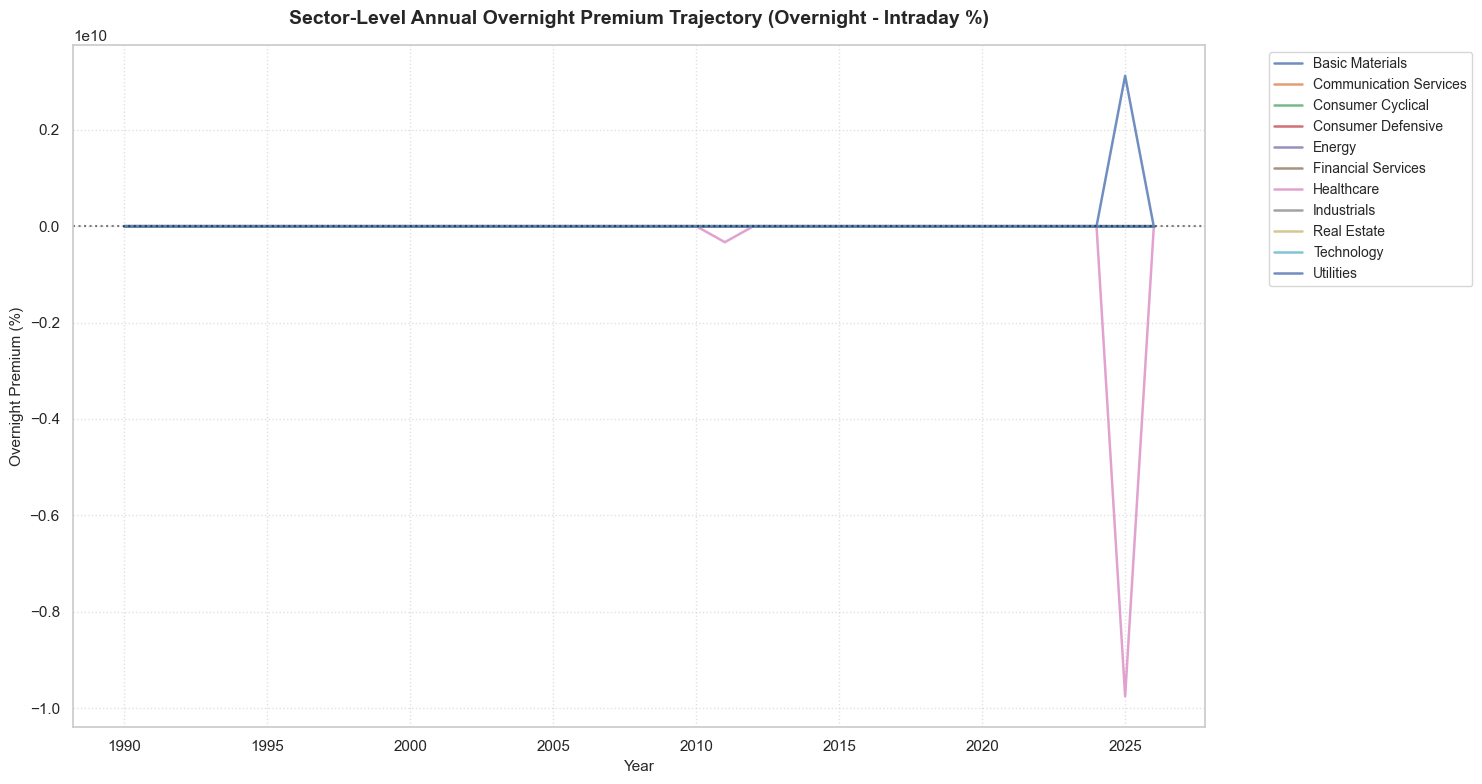

In [10]:
if not panel_df.empty:
    # Pivot to get sector-wise yearly overnight premium (difference)
    sector_yearly = panel_df.groupby(['year', 'sector'])['overnight_minus_intraday_pct'].mean().unstack()

    # Filter out sectors with insufficient or 'Unknown' data
    if 'Unknown' in sector_yearly.columns:
        sector_yearly = sector_yearly.drop(columns=['Unknown'])

    # Plot sector trajectories
    plt.figure(figsize=(15, 8))
    for col in sector_yearly.columns:
        plt.plot(sector_yearly.index, sector_yearly[col], label=col, linewidth=1.8, alpha=0.8)
        
    plt.axhline(0, color='black', linestyle=':', alpha=0.5)
    plt.title("Sector-Level Annual Overnight Premium Trajectory (Overnight - Intraday %)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Year", fontsize=11)
    plt.ylabel("Overnight Premium (%)", fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: panel dataset is empty.")

## Rigorous Trend Slopes & Statistical Significance

To determine which sectors have experienced statistically significant shifts in their overnight holding premiums, we run linear regressions of the sector-level premiums on time (Year) and display the resulting trend slopes, R-squared values, and p-values.

In [ ]:
import scipy.stats as stats

if not panel_df.empty:
    regression_results = []
    sectors = [s for s in panel_df['sector'].unique() if s != 'Unknown']
    
    for sector in sectors:
        sector_data = panel_df[panel_df['sector'] == sector].groupby('year')['overnight_minus_intraday_pct'].mean().reset_index()
        if len(sector_data) < 3:
            continue
            
        slope, intercept, r_value, p_value, std_err = stats.linregress(sector_data['year'], sector_data['overnight_minus_intraday_pct'])
        
        regression_results.append({
            'Sector': sector,
            'Annual Trend Slope (%)': slope,
            'R-Squared': r_value**2,
            'p-value': p_value,
            'Significant Shift (95%)': 'Yes' if p_value < 0.05 else 'No'
        })
        
    reg_df = pd.DataFrame(regression_results).sort_values('Annual Trend Slope (%)', ascending=False)
    print("Statistical Shift of Overnight Premium by Sector Over Time:")
    display(reg_df)
else:
    print("Cannot run regressions: panel dataset is empty.")

## High-Resolution Stock Analysis: Price Chart & Rolling Ratio Subplots

To analyze the behavior at the individual asset level, we create a plotting routine that visualizes the daily candlesticks and volume for any given stock alongside its rolling 60-day positive gain ratio and rolling 60-day negative loss ratio.

Generating Comprehensive Chart and Ratio Shifts for TY...


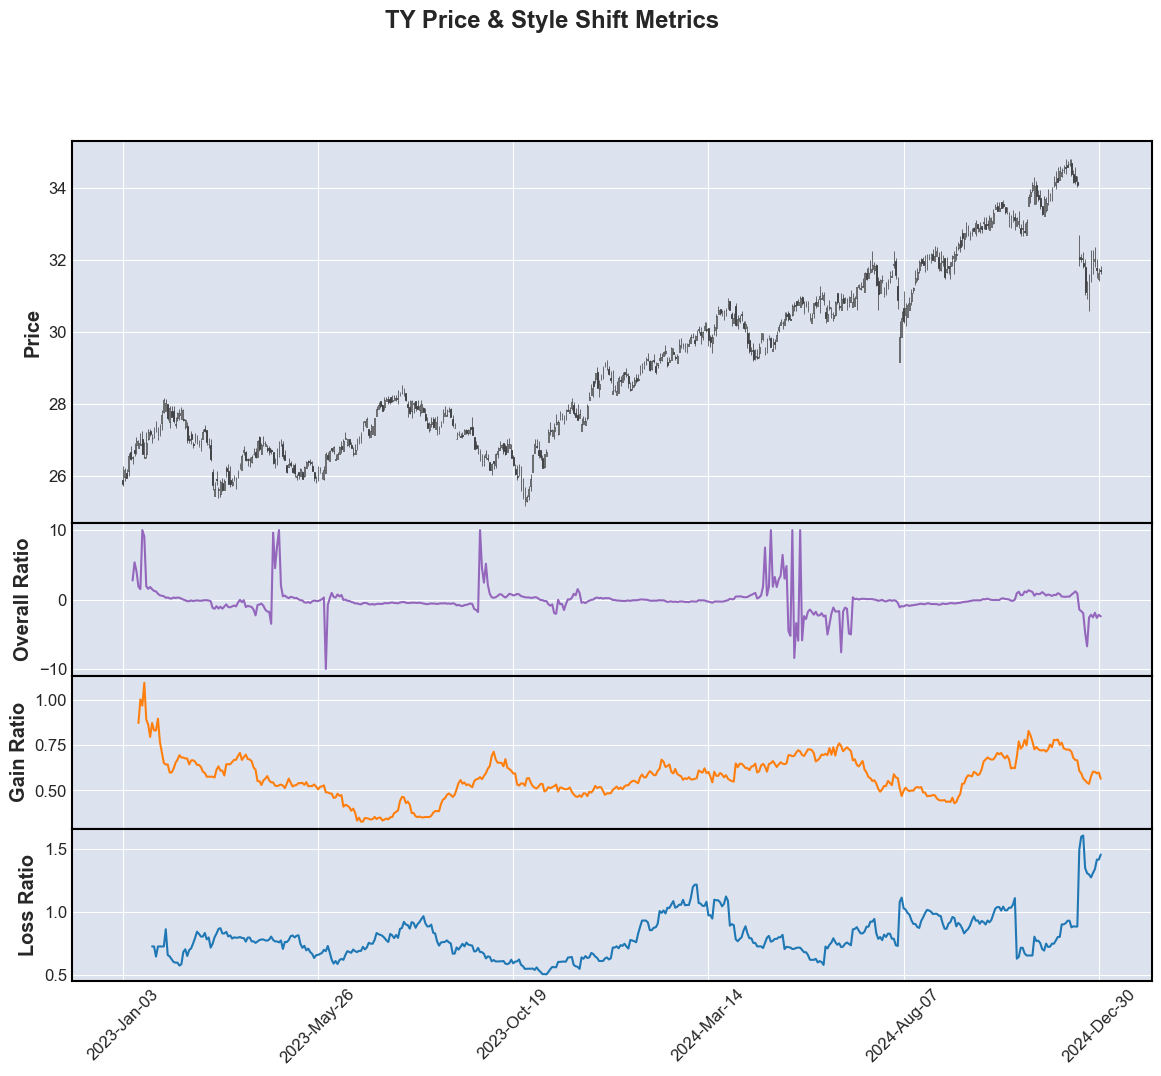

In [25]:
def plot_stock_ohlcv_and_ratios(symbol, start_date='2023-01-01', end_date='2024-12-31', lookback_days=60, figsize=(15, 12)):
    """
    Renders daily candlesticks and rolling ratio subplots for a specific stock.
    Uses pure clipping to stabilize axis scale while keeping plot lines continuous (no gaps).
    """
    symbol_key = str(symbol).replace('.', '_').replace('/', '_')
    file_path = os.path.join(DATA_DIR, symbol_key[0].upper() if symbol_key[0].isalpha() else '0-9', f"{symbol_key}.parquet")
    
    if not os.path.exists(file_path):
        # Try flat fallback
        file_path = os.path.join(DATA_DIR, f"{symbol_key}.parquet")
        if not os.path.exists(file_path):
            print(f"Price file for {symbol} not found.")
            return
            
    df = pd.read_parquet(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').set_index('date')
    sub_df = df.loc[start_date:end_date].copy()
    
    if sub_df.empty:
        print(f"No price data available for {symbol} within the selected date range.")
        return
        
    # Calculate returns and rolling ratios
    close_prev = sub_df['close'].shift(1)
    sub_df['intraday_return'] = (sub_df['close'] - sub_df['open']) / sub_df['open']
    sub_df['overnight_return'] = (sub_df['open'] - close_prev) / close_prev
    
    # 1. Rolling averages of overall returns
    rolling_over = sub_df['overnight_return'].rolling(lookback_days, min_periods=5).mean()
    rolling_intra = sub_df['intraday_return'].rolling(lookback_days, min_periods=5).mean()
    
    # 2. Rolling averages of positive and negative returns
    pos_over = sub_df['overnight_return'].where(sub_df['overnight_return'] > 0).rolling(lookback_days, min_periods=5).mean()
    pos_intra = sub_df['intraday_return'].where(sub_df['intraday_return'] > 0).rolling(lookback_days, min_periods=5).mean()
    neg_over = sub_df['overnight_return'].where(sub_df['overnight_return'] < 0).rolling(lookback_days, min_periods=5).mean()
    neg_intra = sub_df['intraday_return'].where(sub_df['intraday_return'] < 0).rolling(lookback_days, min_periods=5).mean()
    
    # 3. Calculate stabilized ratios (using pure clipping to maintain a continuous, gap-free line)
    sub_df['rolling_overall_ratio'] = (rolling_over / rolling_intra).clip(-10, 10)
    sub_df['rolling_pos_ratio'] = (pos_over / pos_intra).clip(-10, 10)
    sub_df['rolling_neg_ratio'] = (neg_over / neg_intra).clip(-10, 10)
    
    # Add plot configurations using mplfinance
    ap = [
        mpf.make_addplot(sub_df['rolling_overall_ratio'], panel=1, color='#9467bd', width=1.5, ylabel='Overall Ratio'),
        mpf.make_addplot(sub_df['rolling_pos_ratio'], panel=2, color='#ff7f0e', width=1.5, ylabel='Gain Ratio'),
        mpf.make_addplot(sub_df['rolling_neg_ratio'], panel=3, color='#1f77b4', width=1.5, ylabel='Loss Ratio')
    ]
    
    print(f"Generating Comprehensive Chart and Ratio Shifts for {symbol}...")
    mpf.plot(sub_df, type='candle', volume=False, addplot=ap, main_panel=0, num_panels=4, figsize=figsize, title=f"{symbol} Price & Style Shift Metrics")

plot_stock_ohlcv_and_ratios('TY')

In [ ]:
symbol = 'AAPL'
start_date='2022-01-01'
end_date='2024-12-31'
lookback_days=240
figsize=(20, 12)
symbol_key = str(symbol).replace('.', '_').replace('/', '_')
file_path = os.path.join(DATA_DIR, symbol_key[0].upper() if symbol_key[0].isalpha() else '0-9', f"{symbol_key}.parquet")

if not os.path.exists(file_path):
    # Try flat fallback
    file_path = os.path.join(DATA_DIR, f"{symbol_key}.parquet")
    if not os.path.exists(file_path):
        print(f"Price file for {symbol} not found.")
        
df = pd.read_parquet(file_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')
sub_df = df.loc[start_date:end_date].copy()

if sub_df.empty:
    print(f"No price data available for {symbol} within the selected date range.")
    
# Calculate returns and rolling ratios
close_prev = sub_df['close'].shift(1)
sub_df['intraday_return'] = (sub_df['close'] - sub_df['open']) / sub_df['open']
sub_df['overnight_return'] = (sub_df['open'] - close_prev) / close_prev

# Rolling averages of overall returns
rolling_over = sub_df['overnight_return'].rolling(lookback_days, min_periods=30).mean()
rolling_intra = sub_df['intraday_return'].rolling(lookback_days, min_periods=30).mean()
sub_df['rolling_overall_ratio'] = rolling_over / rolling_intra

# Rolling averages of positive and negative returns
pos_over = sub_df['overnight_return'].where(sub_df['overnight_return'] > 0).rolling(lookback_days, min_periods=30).mean()
pos_intra = sub_df['intraday_return'].where(sub_df['intraday_return'] > 0).rolling(lookback_days, min_periods=30).mean()
neg_over = sub_df['overnight_return'].where(sub_df['overnight_return'] < 0).rolling(lookback_days, min_periods=30).mean()
neg_intra = sub_df['intraday_return'].where(sub_df['intraday_return'] < 0).rolling(lookback_days, min_periods=30).mean()

sub_df['rolling_pos_ratio'] = pos_over / pos_intra
sub_df['rolling_neg_ratio'] = neg_over / neg_intra

# Add plot configurations using mplfinance
ap = [
    mpf.make_addplot(sub_df['rolling_overall_ratio'], panel=1, color='#9467bd', width=1.5, ylabel='Overall Ratio'),
    mpf.make_addplot(sub_df['rolling_pos_ratio'], panel=2, color='#ff7f0e', width=1.5, ylabel='Gain Ratio'),
    mpf.make_addplot(sub_df['rolling_neg_ratio'], panel=3, color='#1f77b4', width=1.5, ylabel='Loss Ratio')
]

print(f"Generating Comprehensive Chart and Ratio Shifts for {symbol}...")
mpf.plot(sub_df, type='candle', volume=False, addplot=ap, main_panel=0, num_panels=4, figsize=figsize, title=f"{symbol} Price & Style Shift Metrics")


In [ ]:
i = 60
sub_df.iloc[i:i+20]

In [ ]:
sub_df